<a href="https://colab.research.google.com/github/ii-shimul/ingeet/blob/mahin/LSTM_Model_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Loading Preprocessed Dataset

The dataset was preprocessed in the Data Acquisition and Preprocessing
notebook. The saved NumPy files are loaded here to prepare the data
for LSTM model development.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import numpy as np

data_path = "/content/drive/MyDrive/Ishara/processed_data"

X_train = np.load(data_path + "/X_train.npy")
y_train = np.load(data_path + "/y_train.npy")

X_val = np.load(data_path + "/X_val.npy")
y_val = np.load(data_path + "/y_val.npy")

X_test = np.load(data_path + "/X_test.npy")
y_test = np.load(data_path + "/y_test.npy")

class_names = np.load(
    data_path + "/class_names.npy",
    allow_pickle=True
)

In [6]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("Number of classes:", len(class_names))

X_train: (6514, 44, 258)
y_train: (6514,)
X_val: (1396, 44, 258)
y_val: (1396,)
X_test: (1397, 44, 258)
y_test: (1397,)
Number of classes: 60


In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Input, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [9]:
model = Sequential()

In [14]:
model = Sequential([
    Input(shape=(44, 258)),

    LSTM(128, return_sequences=True),
    LSTM(64, return_sequences=True),
    LSTM(32)
])

In [16]:
model.summary()
print("\nModel output shape:", model.output_shape)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 44, 128)        │       198,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 44, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259,968 (1015.50 KB)

 Trainable params: 259,968 (1015.50 KB)

 Non-trainable params: 0 (0.00 B)


Model output shape: (None, 32)


In [19]:
model.add(Dense(60, activation='softmax'))

In [20]:
model.summary()
print("\nModel output shape:", model.output_shape)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 44, 128)        │       198,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 44, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 60)             │         1,980 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 60)             │         3,660 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 265,608 (1.01 MB)

 Trainable params: 265,608 (1.01 MB)

 Non-trainable params: 0 (0.00 B)


Model output shape: (None, 60)


In [22]:
model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Model Training

The compiled LSTM model is trained using the training dataset.
The validation dataset is used to monitor model performance
during training.

In [23]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.0462 - loss: 4.0470 - val_accuracy: 0.0688 - val_loss: 3.9668
Epoch 2/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 18s 91ms/step - accuracy: 0.0570 - loss: 3.9534 - val_accuracy: 0.0458 - val_loss: 3.9410
Epoch 3/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 18s 79ms/step - accuracy: 0.0488 - loss: 3.9159 - val_accuracy: 0.0487 - val_loss: 3.8915
Epoch 4/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - accuracy: 0.0586 - loss: 3.8583 - val_accuracy: 0.0573 - val_loss: 3.8288
Epoch 5/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - accuracy: 0.0611 - loss: 3.7937 - val_accuracy: 0.0630 - val_loss: 3.7729
Epoch 6/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - accuracy: 0.0614 - loss: 3.7416 - val_accuracy: 0.0630 - val_loss: 3.7168
Epoch 7/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 16s 80ms/step - accuracy: 0.0637 - loss: 3.6922 - val_accuracy: 0.0623 - val_loss: 3.6801
Epoch 8/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - accuracy: 0.0637 - loss: 3.6584 - 

In [24]:
print("Final Training Accuracy:",
      history.history["accuracy"][-1])

print("Final Validation Accuracy:",
      history.history["val_accuracy"][-1])

Final Training Accuracy: 0.09533312916755676
Final Validation Accuracy: 0.09025788307189941


## Training and Validation Performance

The training history is visualized to compare model performance
on the training and validation datasets across epochs.

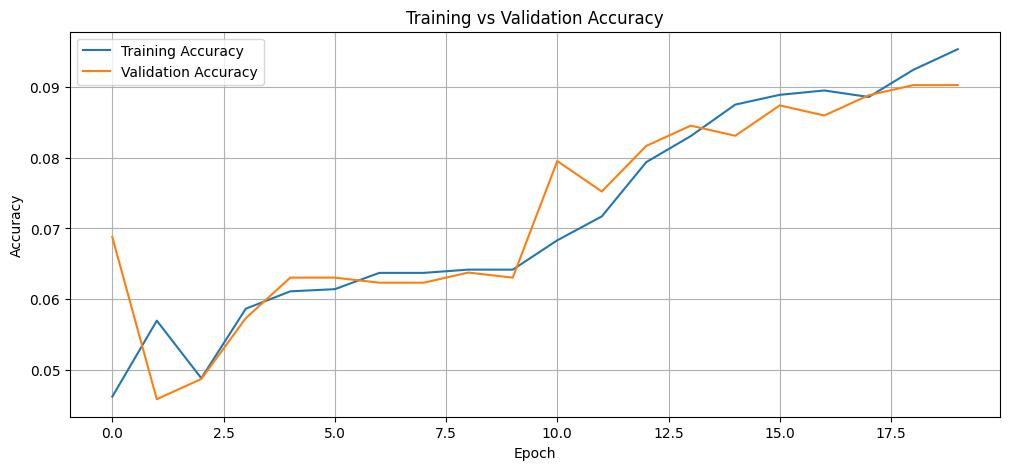

In [26]:
plt.figure(figsize=(12, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

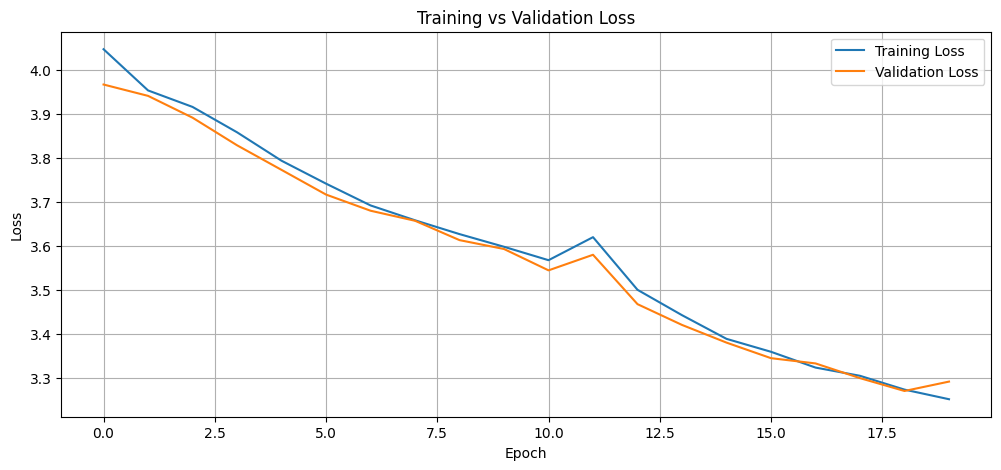

In [27]:
plt.figure(figsize=(12, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Training and Validation Performance Analysis

The training and validation accuracy graphs show a gradual improvement in model performance over 20 epochs. Training accuracy reached approximately 9.53%, while validation accuracy reached approximately 9.03%.

The training and validation loss curves generally decreased throughout training, indicating that the model was learning patterns from the landmark sequences. The relatively small gap between training and validation performance suggests no strong evidence of overfitting during this initial experiment.

However, the overall classification accuracy remains low. Further training, model tuning, and dataset investigation are required to improve sign recognition performance.


In [28]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.0952 - loss: 3.2687
Test Loss: 3.268653154373169
Test Accuracy: 0.09520401060581207


### Test Set Evaluation

The trained LSTM model was evaluated using the held-out test dataset containing 1,397 samples. The model achieved a test accuracy of 9.52% and a test loss of 3.2687.

The test accuracy was close to the training and validation accuracy, indicating similar performance across the data splits. However, the overall accuracy remains low for a 60-class sign-language recognition task. Therefore, this result is considered the baseline performance of the initial model, and further investigation and optimization are needed.


In [29]:
model.save("ishara_lstm_baseline.keras")

In [30]:
from google.colab import files

files.download("ishara_lstm_baseline.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>